<a href="https://colab.research.google.com/github/Narware-Ayush/AI_ML/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# use MLFllow for visulize
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(42)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df=pd.read_csv('/content/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


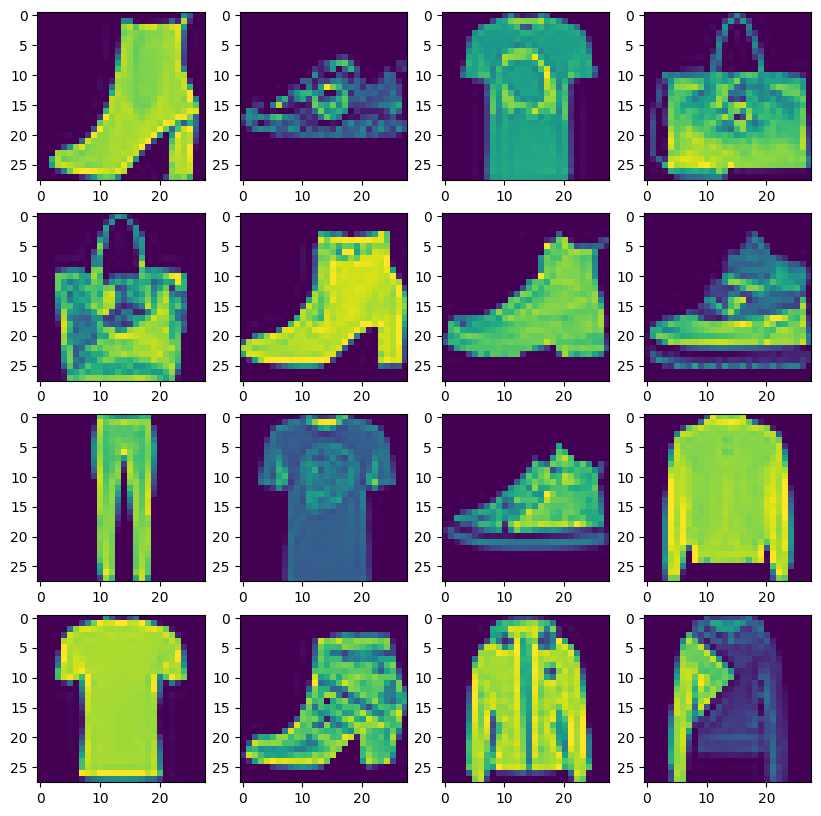

In [3]:
fig, axes=plt.subplots(4,4,figsize=(10,10))
for i ,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)

In [4]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
xtrain=xtrain/255.0
xtest=xtest/255.0


In [5]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):

    self.features=torch.tensor(features,dtype=torch.float32).reshape(-1,1,28,28)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index],self.labels[index]

In [6]:
train_dataset=CustomDataset(xtrain,ytrain)
test_dataset=CustomDataset(xtest,ytest)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)


In [19]:
class MyCNN(nn.Module):
  def __init__(self,input_features):
    super().__init__()

    self.features=nn.Sequential(
        nn.Conv2d(input_features,32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32,6,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(6),
        nn.MaxPool2d(kernel_size=2, stride=2),

    )
    print("After features:", x.shape)
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(6*7*7,128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64,10),
    )

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x

In [20]:
from torch.optim import optimizer
model=MyCNN(1)
model.to(device=device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=0.1,weight_decay=1e-4)

After features: (6000, 784)


In [21]:
epochs=50
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:

    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

    output=model(batch_features)

    loss=criterion(output,batch_labels)
    optimizer.zero_grad()
    loss.backward()

    optimizer.step()
    total_epoch_loss=total_epoch_loss+loss.item()

  avg_loss=total_epoch_loss/len(train_loader)
  print(f'Epoch : {epoch+1} , Loss: {avg_loss}')

Epoch : 1 , Loss: 1.1945065534114838
Epoch : 2 , Loss: 0.7183228009939193
Epoch : 3 , Loss: 0.6137765556573868
Epoch : 4 , Loss: 0.5395550132791201
Epoch : 5 , Loss: 0.4876826093594233
Epoch : 6 , Loss: 0.45282146990299227
Epoch : 7 , Loss: 0.44247699081897734
Epoch : 8 , Loss: 0.4047295372188091
Epoch : 9 , Loss: 0.3797116399308046
Epoch : 10 , Loss: 0.3607984140018622
Epoch : 11 , Loss: 0.3580999035636584
Epoch : 12 , Loss: 0.3240543729563554
Epoch : 13 , Loss: 0.33151109447081883
Epoch : 14 , Loss: 0.311822939713796
Epoch : 15 , Loss: 0.27483371009429297
Epoch : 16 , Loss: 0.2968738230069478
Epoch : 17 , Loss: 0.27155208537975944
Epoch : 18 , Loss: 0.2563564703365167
Epoch : 19 , Loss: 0.2519260304917892
Epoch : 20 , Loss: 0.24583022500077883
Epoch : 21 , Loss: 0.21916254366437593
Epoch : 22 , Loss: 0.21140339829027652
Epoch : 23 , Loss: 0.20883700867493948
Epoch : 24 , Loss: 0.21335502391060193
Epoch : 25 , Loss: 0.18666562056789796
Epoch : 26 , Loss: 0.22694912808636825
Epoch : 27

In [ ]:
# then evaluation